In [7]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.0742999999970197 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [9]:
!mamba install seaborn


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.6034000000059605 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                        pyhd8ed1ab_3                  conda-forge                   
+ statsmodels                   0.14.6                        np22py313h3cf259a_1           emscripten-forge              


In [15]:
# This cell imports all necessary libraries and loads the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("career_dataset_large.csv")
df.head()

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [16]:
# This cell displays basic information about the dataset (shape, types, summary)
df.shape
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Education Level     5000 non-null   str  
 1   Specialization      5000 non-null   str  
 2   Skills              5000 non-null   str  
 3   Certifications      4404 non-null   str  
 4   CGPA/Percentage     5000 non-null   int64
 5   Recommended Career  5000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 136.8 KB


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
count,5000,5000,5000,4404,5000.000000,5000
unique,5,8,757,7,NaN,12
top,Master's,Engineering,Accounting,Mental Health Basics,NaN,Clerk
freq,1028,668,204,674,NaN,432
mean,NaN,NaN,NaN,NaN,77.479800,NaN
std,NaN,NaN,NaN,NaN,10.396288,NaN
min,NaN,NaN,NaN,NaN,60.000000,NaN
25%,NaN,NaN,NaN,NaN,68.000000,NaN
50%,NaN,NaN,NaN,NaN,77.000000,NaN
75%,NaN,NaN,NaN,NaN,87.000000,NaN


In [17]:
# This cell checks for missing values in each column
df.isnull().sum()

Education Level         0
Specialization          0
Skills                  0
Certifications        596
CGPA/Percentage         0
Recommended Career      0
dtype: int64

In [18]:
# This cell calculates the percentage of missing values
(df.isnull().sum() / len(df)) * 100

Education Level        0.00
Specialization         0.00
Skills                 0.00
Certifications        11.92
CGPA/Percentage        0.00
Recommended Career     0.00
dtype: float64

In [19]:
# This cell handles missing values using mean for numerical and mode for categorical
df['CGPA/Percentage'] = df['CGPA/Percentage'].fillna(df['CGPA/Percentage'].mean())

categorical_cols = ['Education Level', 'Specialization', 'Skills', 'Certifications']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [20]:
# This cell checks for duplicate rows in the dataset
df.duplicated().sum()

np.int64(2)

In [21]:
# This cell removes duplicate rows from the dataset
df = df.drop_duplicates()

In [22]:
# This cell shows descriptive statistics for the numerical column (CGPA)
df['CGPA/Percentage'].describe()

count    4998.000000
mean       77.477591
std        10.397609
min        60.000000
25%        68.000000
50%        77.000000
75%        87.000000
max        95.000000
Name: CGPA/Percentage, dtype: float64

In [23]:
# This cell shows frequency counts for categorical variables
df['Education Level'].value_counts()
df['Specialization'].value_counts()
df['Recommended Career'].value_counts()

Recommended Career
Clerk                  432
Marketing Executive    432
ML Engineer            428
Research Scientist     419
Software Engineer      417
School Counselor       417
Financial Analyst      413
Sales Assistant        413
Data Entry Operator    413
Junior Accountant      412
Professor              407
Business Analyst       395
Name: count, dtype: int64

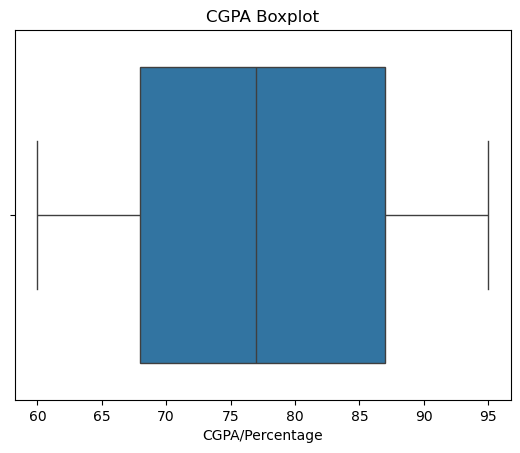

In [24]:
# This cell visualizes outliers in CGPA using a boxplot
sns.boxplot(x=df['CGPA/Percentage'])
plt.title("CGPA Boxplot")
plt.show()

In [25]:
# This cell detects outliers using the IQR method
Q1 = df['CGPA/Percentage'].quantile(0.25)
Q3 = df['CGPA/Percentage'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['CGPA/Percentage'] < lower_bound) | 
              (df['CGPA/Percentage'] > upper_bound)]

outliers

,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career


In [26]:
# This cell handles outliers by capping values within the IQR bounds
df['CGPA/Percentage'] = np.clip(df['CGPA/Percentage'], lower_bound, upper_bound)

In [27]:
# This cell calculates average CGPA for each recommended career
df.groupby('Recommended Career')['CGPA/Percentage'].mean()

Recommended Career
Business Analyst       77.777215
Clerk                  77.199074
Data Entry Operator    77.237288
Financial Analyst      77.230024
Junior Accountant      77.203883
ML Engineer            77.492991
Marketing Executive    78.564815
Professor              77.813268
Research Scientist     77.451074
Sales Assistant        77.898305
School Counselor       77.081535
Software Engineer      76.772182
Name: CGPA/Percentage, dtype: float64

In [28]:
# This cell counts how many times each career appears
df['Recommended Career'].value_counts()

Recommended Career
Clerk                  432
Marketing Executive    432
ML Engineer            428
Research Scientist     419
Software Engineer      417
School Counselor       417
Financial Analyst      413
Sales Assistant        413
Data Entry Operator    413
Junior Accountant      412
Professor              407
Business Analyst       395
Name: count, dtype: int64

In [29]:
# This cell creates a cross-tabulation between education level and career
pd.crosstab(df['Education Level'], df['Recommended Career'])

Recommended Career,Business Analyst,Clerk,Data Entry Operator,Financial Analyst,Junior Accountant,ML Engineer,Marketing Executive,Professor,Research Scientist,Sales Assistant,School Counselor,Software Engineer
Education Level,,,,,,,,,,,,
Bachelor's,77,106,80,79,80,93,91,90,75,79,84,87
Intermediate,91,85,79,86,81,84,84,84,67,71,87,74
Master's,78,87,86,82,77,99,86,71,112,73,88,88
Matric,86,68,90,79,93,67,81,84,88,100,85,93
PhD,63,86,78,87,81,85,90,78,77,90,73,75


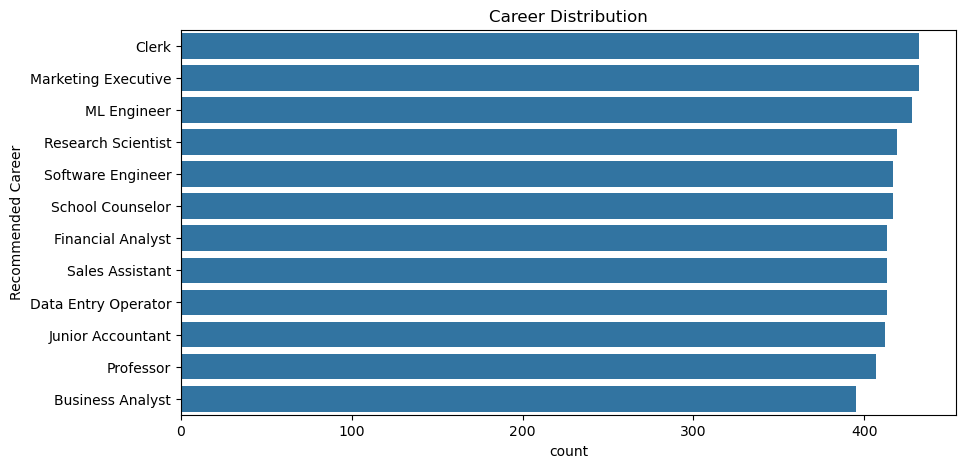

In [30]:
# This cell visualizes the distribution of recommended careers
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Recommended Career', order=df['Recommended Career'].value_counts().index)
plt.title("Career Distribution")
plt.show()

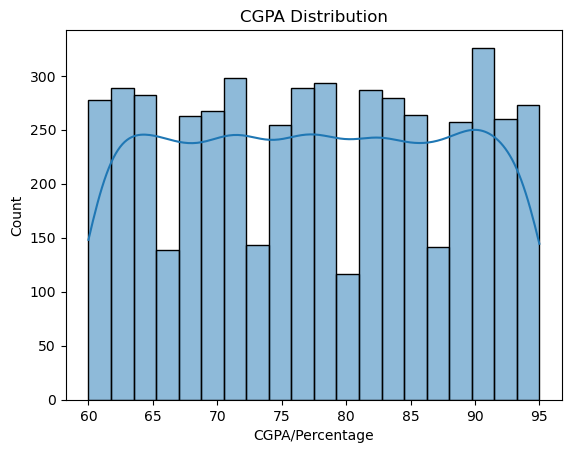

In [31]:
# This cell visualizes the distribution of CGPA values
sns.histplot(df['CGPA/Percentage'], bins=20, kde=True)
plt.title("CGPA Distribution")
plt.show()

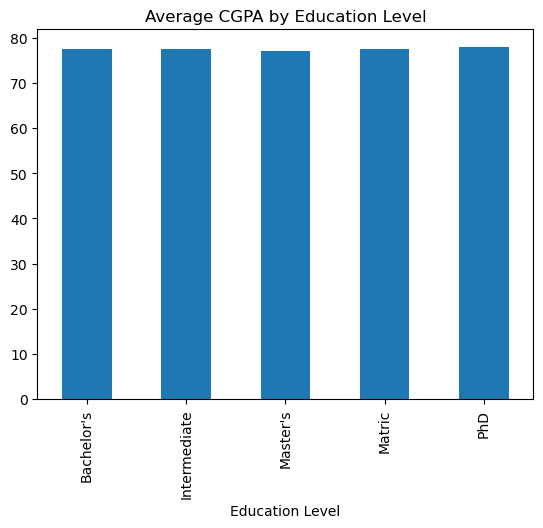

In [32]:
# This cell shows average CGPA by education level using a bar chart
df.groupby('Education Level')['CGPA/Percentage'].mean().plot(kind='bar')
plt.title("Average CGPA by Education Level")
plt.show()

In [ ]:
# This cell shows correlation between numerical variables
df.corr(numeric_only=True)